# 1. Import and Hardware Setup

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.transforms import autoaugment

!pip install tqdm ipywidgets -q
from tqdm.auto import tqdm

import math

In [30]:
DATA_PATH = '.Data'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# 2. Hyperparameters

1. Normal parameters

In [31]:
IN_CHANNELS = 3
BATCH_SIZE = 128
NUM_CLASSES = 101

MODEL_NAME = "EfficientNetV2-S"
EPOCHS = 40
LR = 1e-3
SEED = 42
DROPOUT = 0

2. Adaptive regularization

In [32]:
progressive_configs = {
    "EfficientNetV2-S": {
        "img_size": (128, 300),
        "randaug_mag": (5, 15),
        "mixup_alpha": (0, 0),
        "dropout": (0.1, 0.3),
    },
    "EfficientNetV2-M": {
        "img_size": (128, 380),
        "randaug_mag": (5, 20),
        "mixup_alpha": (0, 0.2),
        "dropout": (0.1, 0.4),
    },
    "EfficientNetV2-L": {
        "img_size": (128, 380),
        "randaug_mag": (5, 25),
        "mixup_alpha": (0, 0.4),
        "dropout": (0.1, 0.5),
    },
    "EfficientNetV2-XL": {
        "img_size": (128, 380),
        "randaug_mag": (5, 25),
        "mixup_alpha": (0, 0.4),
        "dropout": (0.1, 0.5),
    },
}

# Fallback to S if model name not found
config = progressive_configs.get(MODEL_NAME, progressive_configs["EfficientNetV2-S"])

IMG_SIZE_START, IMG_SIZE_END = config["img_size"]
RANDAUG_MAG_START, RANDAUG_MAG_END = config["randaug_mag"]
MIXUP_ALPHA_START, MIXUP_ALPHA_END = config["mixup_alpha"]
DROPOUT_START, DROPOUT_END = config["dropout"]

class ProgressiveScheduler:
    def __init__(self, total_epochs, stages=4):
        self.total_epochs = total_epochs
        self.stages = stages
        self.epochs_per_stage = math.ceil(total_epochs / stages)
    
    def step(self, epoch):
        stage = min(epoch // self.epochs_per_stage, self.stages - 1)
        progress = stage / max(1, self.stages - 1)
        
        img_size = int(IMG_SIZE_START + progress * (IMG_SIZE_END - IMG_SIZE_START))
        randaug = int(
            RANDAUG_MAG_START + progress * (RANDAUG_MAG_END - RANDAUG_MAG_START)
        )
        mixup = MIXUP_ALPHA_START + progress * (MIXUP_ALPHA_END - MIXUP_ALPHA_START)
        dropout = DROPOUT_START + progress * (DROPOUT_END - DROPOUT_START)

        return img_size, randaug, mixup, dropout

prog_scheduler = ProgressiveScheduler(total_epochs=EPOCHS)

# 3. Training Data Preparation

In [33]:
stats = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

def get_transforms(img_size, randaug_mag):
    train_transform = transforms.Compose([
        transforms.Resize(img_size + 32),
        transforms.RandomRotation(15),
        transforms.RandomCrop(img_size),
        transforms.RandAugment(num_ops=2, magnitude=randaug_mag),
        transforms.ToTensor(),
        transforms.Normalize(*stats),
    ])

    test_transform = transforms.Compose([
        transforms.Resize(img_size + 32),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(*stats),
    ])
    
    return train_transform, test_transform

In [34]:
import numpy as np
import random
import os

def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.manual_seed(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

set_seed(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [35]:
# Download data as dummy data without transforms
dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

# Split the dummy data into two temp subset
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
split_generator = torch.Generator().manual_seed(SEED)

train_tmp_subset, val_tmp_subset = random_split(
    dummy_data, [train_size, val_size], generator=split_generator
)

# Extract the indices and create the subsets with correct transforms
train_indices = train_tmp_subset.indices
val_indices = val_tmp_subset.indices

# Create generators for loaders
train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

# 4. Model Architecture

In [36]:
def _make_divisible(old_ch, divisor=8, min_ch=None):
    if min_ch is None:
        min_ch = divisor

    # Calculate new channels
    new_ch = max(min_ch, int(old_ch + divisor // 2) // divisor * divisor)

    # Make sure the new channels doesnt drop too much
    if new_ch < old_ch * 0.9:
        new_ch += divisor
    return new_ch


class ConvNBAct(nn.Sequential):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        stride=1,
        groups=1,
        activation=nn.SiLU,
    ):
        padding = (kernel_size - 1) // 2
        activation = (
            nn.Identity() if activation == nn.Identity else nn.SiLU(inplace=True)
        )
        super().__init__(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                groups=groups,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            activation,
        )


class DropPath(nn.Module):
    def __init__(self, survival_prob: float = 0.8):
        super().__init__()
        self.survival_prob = survival_prob

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self.training or self.survival_prob == 1.0:
            return x

        # Create a empty tensor
        batch_size = x.shape[0]
        noise = torch.empty(batch_size, 1, 1, 1, device=x.device)

        # Fill the tensor with 1s and 0s
        noise.bernoulli_(self.survival_prob)

        # Scale up the signal to make sure that the total training signal
        # is the same with eval, otherwise the prediction will be ruined.
        if self.survival_prob > 0:
            noise.div_(self.survival_prob)

        return x * noise


class SqueezeExcitation(nn.Module):
    def __init__(self, in_channels, hidden_channels, squeeze_factor=4):
        super().__init__()
        squeeze_channels = _make_divisible(in_channels // 4)
        self.block = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(hidden_channels, squeeze_channels, kernel_size=1),
            nn.SiLU(inplace=True),
            nn.Conv2d(squeeze_channels, hidden_channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.block(x)


class MBConv(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        stride,
        expand_ratio,
        fused=False,
        survival_prob=0.8,
    ):
        super().__init__()
        hidden_channels = _make_divisible(in_channels * expand_ratio)
        self.use_res_connect = stride == 1 and in_channels == out_channels
        self.drop_path = (
            DropPath(survival_prob) if self.use_res_connect else nn.Identity()
        )

        layers = []

        # Regular 3x3 conv for FusedMBConv
        if fused:
            layers.append(
                ConvNBAct(
                    in_channels=in_channels,
                    out_channels=hidden_channels,
                    kernel_size=3,
                    stride=stride,
                    groups=1,
                    activation=nn.SiLU,
                )
            )
        else:
            layers.extend([
                    # 1x1 expand conv
                    ConvNBAct(
                        in_channels=in_channels,
                        out_channels=hidden_channels,
                        kernel_size=1,
                        stride=1,
                        groups=1,
                        activation=nn.SiLU,
                    ),
                    # 3x3 dw conv
                    ConvNBAct(
                        in_channels=hidden_channels,
                        out_channels=hidden_channels,
                        kernel_size=3,
                        stride=stride,
                        groups=hidden_channels,
                        activation=nn.SiLU,
                    ),
            ])

        # SqueezeExcitation
        if not fused:
            layers.append(SqueezeExcitation(in_channels, hidden_channels))

        # 1x1 projection conv
        layers.append(
            ConvNBAct(
                in_channels=hidden_channels,
                out_channels=out_channels,
                kernel_size=1,
                activation=nn.Identity,
            )
        )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        out = self.block(x)
        if self.use_res_connect:
            out = self.drop_path(out)
            out = x + out
        return out


class EfficientNetV2(nn.Module):
    def __init__(
        self, model_name, in_channels, num_classes, dropout, drop_connect_rate=0.2
    ):
        super().__init__()

        # [Fused, exp, stride, out, num_layers]
        model_cfg = {
            "EfficientNetV2-S": {
                "configs": [
                    [True, 1, 1, 24, 2],
                    [True, 4, 2, 48, 4],
                    [True, 4, 2, 64, 4],
                    [False, 4, 2, 128, 6],
                    [False, 6, 1, 160, 9],
                    [False, 6, 2, 256, 15],
                ],
                "first_out": 24,
            },
            "EfficientNetV2-M": {
                "configs": [
                    [True, 1, 1, 24, 3],
                    [True, 4, 2, 48, 5],
                    [True, 4, 2, 80, 5],
                    [False, 4, 2, 160, 7],
                    [False, 6, 1, 176, 14],
                    [False, 6, 2, 304, 18],
                    [False, 6, 1, 512, 5],
                ],
                "first_out": 24,
            },
            "EfficientNetV2-L": {
                "configs": [
                    [True, 1, 1, 32, 4],
                    [True, 4, 2, 64, 7],
                    [True, 4, 2, 96, 7],
                    [False, 4, 2, 192, 10],
                    [False, 6, 1, 224, 19],
                    [False, 6, 2, 384, 25],
                    [False, 6, 1, 640, 7],
                ],
                "first_out": 32,
            },
            "EfficientNetV2-XL": {
                "configs": [
                    [True, 1, 1, 32, 4],
                    [True, 4, 2, 64, 8],
                    [True, 4, 2, 96, 8],
                    [False, 4, 2, 192, 16],
                    [False, 6, 1, 256, 24],
                    [False, 6, 2, 512, 32],
                    [False, 6, 1, 640, 8],
                ],
                "first_out": 32,
            },
        }

        total_blocks = sum(
            math.ceil(num_layers)
            for _, _, _, _, num_layers in model_cfg[model_name]["configs"]
        )
        block_id = 0

        # The first 3x3 conv
        layers = []
        out_channels = model_cfg[model_name]["first_out"]
        layers.append(
            ConvNBAct(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=2,
            )
        )
        in_channels = out_channels

        #
        for fused, exp, stride, out, num_layers in model_cfg[model_name]["configs"]:
            for i in range(num_layers):
                stride = stride if i == 0 else 1
                survival_prob = 1.0 - drop_connect_rate * float(block_id) / total_blocks

                layers.append(
                    MBConv(
                        in_channels=in_channels,
                        out_channels=out,
                        stride=stride,
                        expand_ratio=exp,
                        fused=fused,
                        survival_prob=survival_prob,
                    )
                )
                in_channels = out
                block_id += 1

        layers.extend([
            ConvNBAct(
                in_channels=in_channels,
                out_channels=1280,
                kernel_size=1,
            ),
            nn.AdaptiveAvgPool2d(1),
        ])

        self.block = nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1280, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [37]:
print(f"Using: {MODEL_NAME}")
model = EfficientNetV2(
    MODEL_NAME,
    IN_CHANNELS,
    NUM_CLASSES,
    DROPOUT,
).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

Using: EfficientNetV2-S
Total parameters: 20.31M


# 5. Training Preparation

In [38]:
class EarlyStopping:
    """ Stop the training automatically, if the training hits
    Plateau.
    """
    def __init__(
        self, patience=10, delta=0, verbose=False, save_path="best_checkpoint.pth"
    ):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path
        self.verbose = verbose

        self.early_stop = False
        self.counter = 0
        self.best_loss = None
    
    def __call__(self, model, val_loss):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # 2. If the loss didnt decrease as expect
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # 3. The loss decreased properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print("Saving best checkpoint ...")
        state_dict = (
            model.module.state_dict()
            if hasattr(model, "module")
            else model.state_dict()
        )
        torch.save(state_dict, self.save_path)

In [39]:
def generate_cutmix_box(batch_shape, mix_ratio):
    """
    Generate a random CutMix Box for NCHW tensors
    Return: y_min, y_max, x_min, x_max
    """
    img_height = batch_shape[2]
    img_width = batch_shape[3]
    
    mix_scale = math.sqrt(1.0 - mix_ratio)
    cut_height = int(img_height * mix_scale)
    cut_width = int(img_width * mix_scale)
    
    # Center
    cx = np.random.randint(0, img_width)
    cy = np.random.randint(0, img_height)
    
    # Calculate the box coordinates
    x_min = np.clip(cx - cut_width // 2, 0, img_width)
    x_max = np.clip(cx + cut_width // 2, 0, img_width)
    y_min = np.clip(cy - cut_height // 2, 0, img_height)
    y_max = np.clip(cy + cut_height // 2, 0, img_height)
    
    return y_min, y_max, x_min, x_max

def apply_mixup_cutmix(x, y, p=0.5, alpha=1.0, cutmix_prob=0.5):
    """Returns:
        - x_mixed: The augmented images
        - y_a: The original labels of the current batch
        - y_b: The suffled labels
        - lam: The mix coefficient
        - use_mix: True or False
    """
    use_mix = np.random.rand() < p

    # 1. Not using mix
    if not use_mix:
        return x, y, y, 1.0, False
    
    # 2. Using mix
    # Generate the mixing coefficient
    lam = float(np.random.beta(alpha, alpha))
    
    # Generate a shuffled list of indices to decide which
    # images in the batch will be mixed together
    rand_index = torch.randperm(x.size(0), device=x.device)
    y_a, y_b = y, y[rand_index]
    
    # CutMix
    if np.random.rand() < cutmix_prob:
        # Clone the image
        x = x.clone()
        
        # Get the box coordinates
        y_min, y_max, x_min, x_max = generate_cutmix_box(x.size(), lam)
        
        # Put the other image in the box
        x[:, :, y_min:y_max, x_min:x_max] = x[rand_index, :, y_min:y_max, x_min:x_max]
        
        # Recalculate new lamda coefficient
        lam = 1.0 - ((y_max - y_min) * (x_max - x_min) / (x.size(-2) * x.size(-1)))
    # MixUp
    else:
        x = lam * x + (1.0 - lam) * x[rand_index, :]
    return x, y_a, y_b, lam, True

In [40]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer=optimizer,
    max_lr=LR,
    epochs=EPOCHS,
    steps_per_epoch=math.ceil(len(train_tmp_subset) / BATCH_SIZE),
    pct_start=0.15,
    div_factor=10,
    final_div_factor=100,
)

# Scaler for using AMP - Mixed Precision
scaler = torch.amp.GradScaler(device)

In [41]:
def train(model, loader, criterion, optimizer, scheduler, scaler, mixup_alpha):
    model.train()
    train_loss, train_acc = 0.0, 0.0
    loop = tqdm(loader, desc="Training", leave=False)

    for x, y in loop:
        # Move samples and labels to device
        x, y = x.to(device), y.to(device)

        # Zero out the gradient from the last batch
        optimizer.zero_grad(set_to_none=True)

        # Using CutMix/MixUp with progressive alpha
        x, y_a, y_b, lam, use_mix = apply_mixup_cutmix(
            x,
            y,
            p=0.5 if mixup_alpha > 0 else 0.0,
            alpha=mixup_alpha,
        )

        with torch.amp.autocast(device_type=device.type):
            # Get prediction
            out = model(x)

            # Get the loss
            loss = (
                lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                if use_mix
                else criterion(out, y)
            )

        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()

        # Unscale the gradients and clip
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update the parameters
        scaler.step(optimizer)

        # Update the scaler
        scaler.update()

        # Update lr after each batch because of using OneCycleLR
        scheduler.step()

        train_loss += loss.detach() * x.size(0)
        if use_mix:
            train_acc += (
                lam * (out.argmax(1) == y_a)
                + (1.0 - lam) * (out.argmax(1) == y_b).float()
            ).sum()
        else:
            train_acc += (out.argmax(1) == y).sum()

    return train_loss.item() / len(loader.dataset), train_acc.item() / len(
        loader.dataset
    )

def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            with torch.amp.autocast(device_type=device.type):
                out = model(x)
                loss = criterion(out, y)
            val_loss += loss.detach() * x.size(0)
            val_acc += (out.argmax(1) == y).sum()
    return val_loss.item() / len(loader.dataset), val_acc.item() / len(loader.dataset)


def test(model, loader):
    model.eval()
    test_acc = 0.0
    loop = tqdm(loader, desc="Testing", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)
            test_acc += (out.argmax(1) == y).sum()
    return test_acc / len(loader.dataset)

# 6. Train

In [42]:
def update_dropout(model, new_dropout):
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.p = new_dropout


train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
early_stopping = EarlyStopping(patience=10, delta=0.01)

current_img_size = 0

for epoch in range(EPOCHS):
    img_size, randaug_mag, mixup_alpha, dropout = prog_scheduler.step(epoch)

    # Update progressive learning parameters and Dataloaders
    if img_size != current_img_size or epoch == 0:
        current_img_size = img_size
        print(f"\n[Stage Update] Epoch {epoch+1}:")
        print(f"  -> Img Size: {img_size}, RandAug Mag: {randaug_mag}, Mixup Alpha: {mixup_alpha:.2f}, Dropout: {dropout:.2f}")

        train_transform, test_transform = get_transforms(img_size, randaug_mag)

        # Create datasets with new transforms because persistent_workers=True
        train_tmp_subset = datasets.Food101(
            root=DATA_PATH, split="train", download=False, transform=train_transform
        )
        val_tmp_subset = datasets.Food101(
            root=DATA_PATH, split='train', download=False, transform=test_transform
        )
        test_dataset = datasets.Food101(
            root=DATA_PATH, split='test', download=False, transform=test_transform
        )
        
        train_subset = Subset(train_tmp_subset, train_indices)
        val_subset = Subset(val_tmp_subset, val_indices)
        
        # Create dataloaders
        train_loader = DataLoader(
            train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4,
            pin_memory=True, persistent_workers=True, prefetch_factor=2,
            worker_init_fn=seed_worker, generator=train_generator
        )
        val_loader = DataLoader(
            val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4,
            pin_memory=True, persistent_workers=True, prefetch_factor=2,
            worker_init_fn=seed_worker, generator=eval_generator
        )
        test_loader = DataLoader(
            test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4,
            pin_memory=True, persistent_workers=True, prefetch_factor=2,
            worker_init_fn=seed_worker, generator=eval_generator
        )
        
        update_dropout(model, dropout)
    
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scheduler, scaler, mixup_alpha)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, " +
          f"train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")
    
    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early Stopping")
        break

best_model = model.module if hasattr(model, 'module') else model
best_model.load_state_dict(torch.load('best_checkpoint.pth', map_location=device))
test_acc = test(model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")
    


[Stage Update] Epoch 1:
  -> Img Size: 128, RandAug Mag: 5, Mixup Alpha: 0.00, Dropout: 0.10


Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 1/40: train_loss: 4.6087, val_loss: 4.4619, train_acc: 0.0147, val_acc: 0.0341


Training:   0%|          | 0/474 [00:00<?, ?it/s]

...

Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 30/40: train_loss: 1.2320, val_loss: 1.7797, train_acc: 0.8740, val_acc: 0.7206

[Stage Update] Epoch 31:
  -> Img Size: 300, RandAug Mag: 15, Mixup Alpha: 0.00, Dropout: 0.30


Training:   0%|          | 0/474 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 86.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 55.81 MiB is free. Including non-PyTorch memory, this process has 14.50 GiB memory in use. Of the allocated memory 13.90 GiB is allocated by PyTorch, and 465.30 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

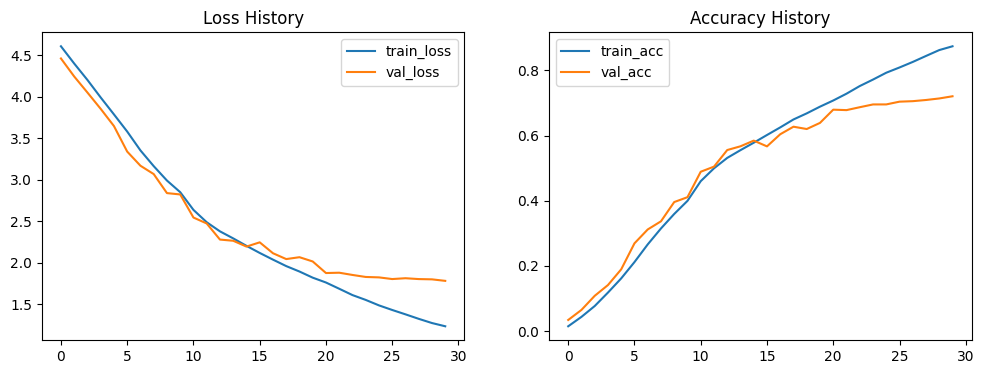

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='train_acc')
plt.plot(val_accuracies, label='val_acc')
plt.title('Accuracy History')
plt.legend()

# 7. GradCAM

In [44]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks to capture the features and gradients
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        # grad_output[0] contains the gradients for the layer's output
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_image, target_class=None):
        self.model.eval()
        
        # 1. Forward pass
        model_output = self.model(input_image)
        
        # If no target class is specified, use the predicted class
        if target_class is None:
            target_class = model_output.argmax(dim=1).item()
            
        # 2. Backward pass for the target class
        self.model.zero_grad()
        target_score = model_output[0, target_class]
        target_score.backward()

        # 3. Calculate weights using Global Average Pooling on the gradients
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)

        # 4. Multiply weights by activations to get the raw heatmap
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)

        # 5. Apply ReLU (we only care about features that have a positive influence)
        cam = F.relu(cam)
        
        # 6. Resize the heatmap to match the original image dimensions
        cam = F.interpolate(
            cam, 
            size=(input_image.shape[2], input_image.shape[3]), 
            mode='bilinear', 
            align_corners=False
        )
        
        # 7. Normalize the heatmap to be between 0 and 1
        cam = cam.squeeze().cpu().detach().numpy()
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8)
        
        return cam

def plot_gradcam(image_tensor, cam_heatmap):
    # Convert tensor image to numpy format (Height, Width, Channels)
    img = image_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    
    # Denormalize the image using your exact dataset stats
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    # Create the color heatmap using matplotlib's jet colormap
    jet = plt.get_cmap('jet')
    heatmap_colored = jet(cam_heatmap)[..., :3] # Remove alpha channel
    
    # Create the final overlay
    overlay = heatmap_colored * 0.4 + img * 0.6
    overlay = np.clip(overlay, 0, 1)

    # Plot the results side-by-side
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    ax[1].imshow(cam_heatmap, cmap='jet')
    ax[1].set_title('GradCAM Heatmap')
    ax[1].axis('off')
    
    ax[2].imshow(overlay)
    ax[2].set_title('Overlay')
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# Example Usage with EfficientNetV2
# ==========================================

# Step 1: Define the target layer
# In the EfficientNetV2 class, `self.block` contains the sequential layers.
# The absolute last layer is `nn.AdaptiveAvgPool2d(1)` (index -1).
# The optimal layer for GradCAM is the last ConvBNAct block right before the pooling (index -2).
target_layer = model.block[-2]

# Step 2: Initialize GradCAM
grad_cam = GradCAM(model, target_layer)

# Step 3: Get a sample image from the test loader
sample_images, sample_labels = next(iter(test_loader))
sample_image = sample_images[0:1].to(device) # Keep batch dimension of 1

# Step 4: Generate and plot the heatmap
heatmap = grad_cam.generate_heatmap(sample_image)
plot_gradcam(sample_image, heatmap)


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 1.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.15 GiB is allocated by PyTorch, and 252.39 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)